# Useful imports

In [316]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time
import copy

# Matrix operations

In [317]:
def multiply_row(row, mul, X):
    for col in range(len(X[row])):
        X[col][row] *= mul

def add_row(row1, row2, mul, X):
    for col in range(len(X[row1])):
        X[col][row1] += X[col][row2] * mul

def swap_rows(row1, row2, X):
    for col in range(len(X[row1])):
        X[col][row1], X[col][row2] = X[col][row2], X[col][row1]

def swap_cols(col1, col2, X):
    for row in range(len(X[col1])):
        X[col1][row], X[col2][row] = X[col2][row], X[col1][row]

def print_matrix(X):
    N = len(X) - 1
    for row in range(N):
        for col in range(N + 1):
            print(int(X[col][row]), end=" ")
        print()

# Random matrices and vectors for testing purposes

In [318]:

def random_matrix(N):
    return [[random.randrange(0, 10) for row in range(N)] for col in range(N)]


def random_vector(N):
    return [random.randrange(0, 10) for row in range(N)]

# Pivoting

In [319]:

def partial_pivot(col, X):
    mx, mxidx = -1, -1
    l = len(X[col]) - col 
    for offdown in range(l):
        if abs(X[col][offdown+col]) > mx:
            mx = abs(X[col][offdown+col])
            mxidx = offdown + col
    return (col, mxidx) 

def full_pivot(col, X):
    mx, mxidx = -1, (-1, -1)
    l = len(X[col]) - col 
    for offdown in range(l):
        for offright in range(l):
            if abs(X[col+offright][col+offdown]) > mx:
                mx = abs(X[col+offright][col + offdown])
                mxidx = col+offright, col+offdown
    return mxidx


# Gaussian elimination implementation.
Additionally takes the alternative pivoting function as an argument

In [320]:

def gauss_jordan(Xin, B, pivot_fun=partial_pivot):
    X = copy.deepcopy(Xin)
    N = len(X)
    if N != len(B):
        print("array size mismatch")
        return None

    # appending B vector to X
    X.append(B)

    # gaussian elimination
    for col in range(N):
        p_col, p_row = pivot_fun(col, X)
        if p_row != col: 
            swap_rows(p_row, col, X)
        if p_col != col: 
            swap_cols(p_col, col, X)
        mul = 1 / X[col][col]
        multiply_row(col, mul, X)
        
        X[col][col] = 1

        for row in range(N):
            if row != col:
                add_row(row, col, -X[col][row], X)
                X[col][row] = 0

    return X

def solve_partial(X, B):
    res = gauss_jordan(X, B)
    if not res:
        return res
    return res[-1]

def solve_full(X, B):
    res = gauss_jordan(X, B, full_pivot)
    if not res:
        return res
    return res[-1]


# Comparing own implementation vs numpy

Interestingly enough my implementation seems to be orders of magnitude slower than that of numpy. Although numpy is written in C and my code has not been written with speed in mind

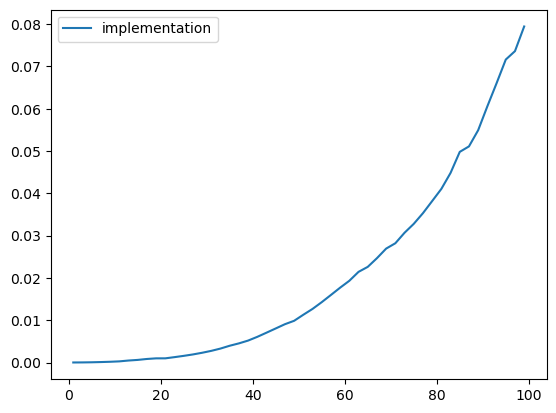

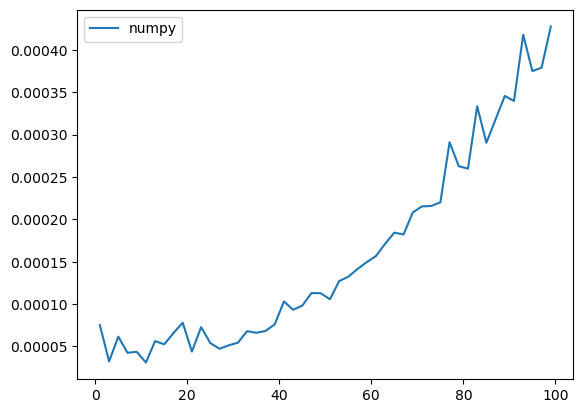

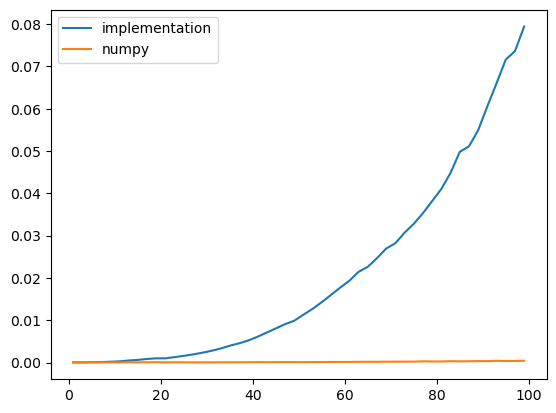

In [321]:

def compare_exec_times():
    plot_Y1 = []
    plot_Y2 = []

    Ns = list(range(1,100,2))
    for N in Ns:
        X = random_matrix(N)
        B = random_vector(N)
        timer = time.time()
        solve_full(X, B)
        plot_Y1.append(time.time() - timer)
        timer = time.time()
        np.linalg.solve(X, B)
        plot_Y2.append(time.time() - timer)

    plt.plot(Ns, plot_Y1, label="implementation")
    plt.legend()
    plt.show()
    plt.plot(Ns, plot_Y2, label="numpy")
    plt.legend()
    plt.show()

    plt.plot(Ns, plot_Y1, label="implementation")
    plt.plot(Ns, plot_Y2, label="numpy")
    plt.legend()
    plt.show()
compare_exec_times()